# Kicker Strategy - Results

In [1]:
import pandas as pd
import numpy as np
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.proportion import proportions_ztest
import scipy.stats as stats

### Data Import

In [2]:
results = glob.glob("results/*.json")
file_list = []

for files in results:
    # Open files
    with open(files, "r") as file:
        data = json.load(file)

    events_list = []
    # Assign filename to "game" column
    game = os.path.basename(files).replace(".json", "")

    # Loop through the runs
    for run in data.get("runs", []):
        run_id = run["run_id"]
        player_1 = run["player_1"]
        player_2 = run["player_2"]
        # Loop through events
        for event in run.get("events", []):
            events_list.append({
                "game": game,
                "run_id": run_id,
                "player_1": player_1,
                "player_2": player_2,
                "timestamp": event["timestamp"],
                "player": event["player"],
                "event_type": event["type"],
                "bar": event.get("bar", pd.NA),
                "side": event.get("side", pd.NA),
                "is_goal": event.get("successful", False) #True if successful, False if not successful
            })

    # Convert to dataframe
    df_game = pd.DataFrame(events_list)
    file_list.append(df_game)

timestamped_data = pd.concat(file_list, ignore_index=True)
timestamped_data = timestamped_data.sort_values(by=["game", "run_id", "timestamp"]).reset_index(drop=True)
timestamped_data["is_shot"] = timestamped_data["event_type"] == "shot"

timestamped_data['round'] = timestamped_data.groupby(['game', 'run_id'])['is_goal'].shift(fill_value=False).cumsum() + 1 #counts up whenever the previous row was a goal (shift function moves it down 1 row)
timestamped_data['is_contact_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 1 contact
timestamped_data['is_contact_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 2 contact
timestamped_data['is_shot_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 1 shot
timestamped_data['is_shot_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 2 shot

timestamped_data['prev_player'] = timestamped_data.groupby(['game', 'run_id'])['player'].shift(1) #shift(1) -> taking the row above
timestamped_data['prev_bar'] = timestamped_data.groupby(['game', 'run_id'])['bar'].shift(1)
timestamped_data['prev_side'] = timestamped_data.groupby(['game', 'run_id'])['side'].shift(1)
timestamped_data['prev_event'] = timestamped_data.groupby(['game', 'run_id'])['event_type'].shift(1)
timestamped_data['prev_timestamp'] = timestamped_data.groupby(['game', 'run_id'])['timestamp'].shift(1)

#noramlizing the prev_side column for player 2 for side hypotheses
timestamped_data['prev_side_normalized'] = timestamped_data['prev_side']
is_p2 = timestamped_data['prev_player'] == timestamped_data['player_2']
timestamped_data.loc[is_p2, 'prev_side_normalized'] = timestamped_data.loc[is_p2, 'prev_side'].map({'Left': 'Right', 'Right': 'Left'}).fillna(timestamped_data['prev_side'])

timestamped_data['possession_change'] = timestamped_data['player'] != timestamped_data['player'].shift()
timestamped_data['possession_id'] = timestamped_data['possession_change'].cumsum()
timestamped_data['possession_length'] = timestamped_data.groupby('possession_id').cumcount() + 1

shots = timestamped_data[timestamped_data["event_type"] == "shot"].copy()
shots["hold_time"] = shots["timestamp"] - timestamped_data.groupby(["game", "run_id"])["timestamp"].shift(1)
shots = shots[(shots["hold_time"] > 0) & (shots["hold_time"].notna())]
shots["prev_bar_clean"] = shots["prev_bar"].str.replace(r"\d+", "", regex=True).str.strip()

shots["p1_scored"] = ((shots["player"] == shots["player_1"]) & (shots["is_goal"] == True)).astype(int)
shots["p2_scored"] = ((shots["player"] == shots["player_2"]) & (shots["is_goal"] == True)).astype(int)
shots["points_p1"] = shots.groupby(["game", "run_id"])["p1_scored"].cumsum().shift(1).fillna(0)
shots["points_p2"] = shots.groupby(["game", "run_id"])["p2_scored"].cumsum().shift(1).fillna(0)

#aggregating the data for each round
round_data = timestamped_data.groupby(['game', 'run_id', 'round']).agg( #aggregating the data for each round
    start=('timestamp', 'min'), #minimum timestamp in all of the rows for a round -> minimum -> first row
    end=('timestamp', 'max'), #maximum timestamp in all of the rows for a round -> maximum -> last row
    player_1=('player_1', 'first'), #just takes the value of the first row of a round -> doesn't matter because it's the same in all of the rows
    player_2=('player_2', 'first'), 
    contacts_p1=('is_contact_p1', 'sum'), #sum of all the contacts for player 1 (count of True in the boolean column see above)
    contacts_p2=('is_contact_p2', 'sum'), 
    shots_p1=('is_shot_p1', 'sum'),
    shots_p2=('is_shot_p2', 'sum')
).reset_index()

round_data.columns = ['game', 'run_id', 'round', 'start', 'end', 'player_1', 'player_2', 'contacts_p1', 'contacts_p2', 'shots_p1', 'shots_p2']

winners = timestamped_data[timestamped_data['is_goal']].set_index(['game', 'run_id', 'round'])['player'] #filters the goal rows and then extracts the player who shot the goal (=winner) for each round
round_data = round_data.join(winners, on=['game', 'run_id', 'round']).rename(columns={'player': 'round_winner'}) #joins the winner on game, run_id and round

round_data['duration'] = round_data['end'] - round_data['start'] #calculating duration
round_data['p1_won_round'] = (round_data['round_winner'] == round_data['player_1']) #boolean column whether player 1 won the round
round_data['p2_won_round'] = (round_data['round_winner'] == round_data['player_2']) #boolean columns whether player 2 won the round

round_data['points_p1'] = round_data.groupby(['game', 'run_id'])['p1_won_round'].transform('cumsum') #counts up if player 1 won
round_data['points_p2'] = round_data.groupby(['game', 'run_id'])['p2_won_round'].transform('cumsum') #counts up if player 2 won

round_data.drop(columns=['game','p1_won_round', 'p2_won_round'], inplace=True) #dropping unneccessary columns

### Data Overview

In [3]:
timestamped_data.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,...,is_shot_p2,prev_player,prev_bar,prev_side,prev_event,prev_timestamp,prev_side_normalized,possession_change,possession_id,possession_length
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False,...,False,NaN,NaN,NaN,NaN,NaN,NaN,True,1,1
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False,...,False,Diana,Middle1,Middle,contact,2.985530,Middle,False,1,2
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False,...,False,Diana,Attack1,Right,contact,3.749828,Right,True,2,1
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True,...,True,Hans,Attack2,Middle,contact,6.102422,Middle,False,2,2
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False,...,False,Hans,NaN,NaN,shot,10.453081,NaN,True,3,1


In [4]:
round_data.head()

,run_id,round,start,end,player_1,player_2,contacts_p1,contacts_p2,shots_p1,shots_p2,round_winner,duration,points_p1,points_p2
0,0,1,2.985530,10.453081,Diana,Hans,2,1,0,1,Hans,7.467551,0,1
1,0,2,20.291921,51.365341,Diana,Hans,5,5,3,2,Diana,31.073420,1,1
2,0,3,56.560030,150.898025,Diana,Hans,15,17,5,7,Diana,94.337994,2,1
3,0,4,164.168779,178.463446,Diana,Hans,3,2,3,1,Diana,14.294667,3,1
4,0,5,191.487753,208.643816,Diana,Hans,4,5,3,2,Hans,17.156064,3,2


# 4. Core Results

## 4.1 Ball Control and Pacing Dynamics

### 4.1.1 Plots and Results

##### Hold Time

In [5]:
player_hold_time = (shots.groupby("player")["hold_time"].mean().reset_index().rename(columns={"hold_time": "avg_hold_time"}))
player_hold_time.sort_values(by="avg_hold_time", ascending=True)

,player,avg_hold_time
0,Diana,1.808285
2,Magnus,2.084011
3,Olga,2.579928
4,Simon,2.923587
5,Tanja,2.950816
1,Hans,4.200696


#### Tanja Hold Time

In [6]:
tanja_shots = shots[shots["player"] == "Tanja"].copy()
is_p1 = (tanja_shots["player_1"] == "Tanja")

tanja_shots["is_winning"] = np.where(is_p1, tanja_shots["points_p1"] > tanja_shots["points_p2"], tanja_shots["points_p2"] > tanja_shots["points_p1"])
tanja_shots["is_losing"] = np.where(is_p1, tanja_shots["points_p1"] < tanja_shots["points_p2"], tanja_shots["points_p2"] < tanja_shots["points_p1"])
tanja_shots["score_state"] = np.select([tanja_shots["is_winning"], tanja_shots["is_losing"]], ["Winning", "Losing"], default="Tied")

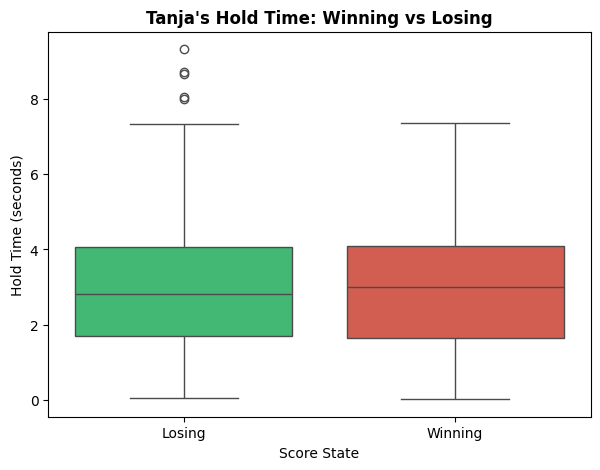

In [7]:
# Plot for Tanja's Hold time
plt.figure(figsize=(7, 5))
sns.boxplot(data=tanja_shots[tanja_shots["score_state"].isin(["Winning", "Losing"])], x="score_state", y="hold_time", hue="score_state",
            palette=["#2ecc71", "#e74c3c"])
plt.title("Tanja's Hold Time: Winning vs Losing", fontweight="bold")
plt.ylabel("Hold Time (seconds)")
plt.xlabel("Score State")
plt.show()

#### Posession Length

In [8]:
player_posession_length = (shots.groupby("player")["possession_length"].mean().reset_index().rename(columns={"possession_length": "avg_posession_length"}))
player_posession_length.sort_values(by="avg_posession_length", ascending=True)

,player,avg_posession_length
1,Hans,2.823477
5,Tanja,3.105461
0,Diana,3.165929
2,Magnus,3.281563
4,Simon,3.384787
3,Olga,4.067771


### 4.1.2 Hypotheses

#### Hypothesis 1: Hans holds the ball longer before taking a shot compared to the other players

H0: There is no statistically significant difference between Hans's hold time and the hold time of the other players.

H1: Hans has a statistically significant higher hold time compared to the other players.

In [9]:
scaler = StandardScaler()
hold_time_values = player_hold_time["avg_hold_time"].values.reshape(-1, 1)
player_hold_time["z_score"] = scaler.fit_transform(hold_time_values)
player_hold_time.sort_values(by="z_score", ascending=True)

,player,avg_hold_time,z_score
0,Diana,1.808285,-1.237344
2,Magnus,2.084011,-0.878069
3,Olga,2.579928,-0.231883
4,Simon,2.923587,0.215909
5,Tanja,2.950816,0.251389
1,Hans,4.200696,1.879998


Hans's hold time is almost 1.9 standard deviations above the group mean.

Statistical results:

We're using a right-tailed Welch's t-test to compare the mean hold times.

We define $\mu_{\text{Hans}}$ as the mean hold time of Hans and $\mu_{\text{Others}}$ as the aggregated mean hold time of the other players.

$$H_0: \mu_{\text{Hans}} \le \mu_{\text{Others}}$$
$$H_1: \mu_{\text{Hans}} > \mu_{\text{Others}}$$

In [10]:
hans_hold_times = shots.loc[shots["player"] == "Hans", "hold_time"]
others_hold_times = shots.loc[shots["player"] != "Hans", "hold_time"]

t_stat, p_value = stats.ttest_ind(hans_hold_times, others_hold_times, equal_var=False, alternative="greater")

print(f"p value: {p_value:.4e}")

p value: 1.0118e-91


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 2: Diana holds the ball shorter before taking a shot compared to the other Players

H0: There is no statistically significant difference between Diana's hold time and the hold time of the other players.

H1: Diana has a statistically significant shorter hold time compared to the other players.

In [11]:
# similar to hans we can compare the z-scores and average hold time for all players
hold_time_values = player_hold_time["avg_hold_time"].values.reshape(-1, 1)
player_hold_time["z_score"] = scaler.fit_transform(hold_time_values)
player_hold_time.sort_values(by="z_score", ascending=True)

,player,avg_hold_time,z_score
0,Diana,1.808285,-1.237344
2,Magnus,2.084011,-0.878069
3,Olga,2.579928,-0.231883
4,Simon,2.923587,0.215909
5,Tanja,2.950816,0.251389
1,Hans,4.200696,1.879998


Diana's average hold time is almost 1.8s  which is the lowest amongst all the players.

In [12]:
diana_hold_times = shots.loc[shots["player"] == "Diana", "hold_time"]
others_hold_times = shots.loc[shots["player"] != "Diana", "hold_time"]

t_stat, p_value = stats.ttest_ind(diana_hold_times, others_hold_times, equal_var=False, alternative="less")

print(f"p value: {p_value:.4e}")

p value: 1.5266e-182


The p-value is less than 0.05. There is strong evidence for rejecting the null hypothesis and accepting the alternative hypothesis.

#### Hypothesis 3: Tanja has a shorter hold time when she is losing compared to when she is Winning

H0: Tanja's average hold time when losing is greater or equal to her hold time when winning.

H1: Tanja's average hold time when losing is strictly less than her hold time when winning.

In [13]:
# Get hold time when winning and losing
win_holds = tanja_shots[tanja_shots["score_state"] == "Winning"]["hold_time"].dropna()
lose_holds = tanja_shots[tanja_shots["score_state"] == "Losing"]["hold_time"].dropna()

In [14]:
# Use Welch's T-Test
t_stat, p_val = stats.ttest_ind(lose_holds, win_holds, equal_var=False, alternative='less')

print(f"Tanja Avg Hold Time when Winning: {win_holds.mean():.2f}s")
print(f"Tanja Avg Hold Time when Losing: {lose_holds.mean():.2f}s")
print(f"Welch's T-Statistic: {t_stat:.4f}, P-Value: {p_val:.4f}")

Tanja Avg Hold Time when Winning: 3.01s
Tanja Avg Hold Time when Losing: 2.95s
Welch's T-Statistic: -0.4874, P-Value: 0.3131


Statistical Results:
With a p-value of 0.313, the results are not statistically significant (p > 0.05).

Therefore, we fail to reject the null hypothesis. There is not enough evidence in this data to support the claim that Tanja has a shorter hold time when she is losing compared to when she is winning.

Although the data shows a slightly lower average hold time when losing, this difference is small and could easily be due to random variation.

## 4.2 Passing and Playmaking Strategies

### 4.2.1 Plots and Results

#### Goal success rate after back passes

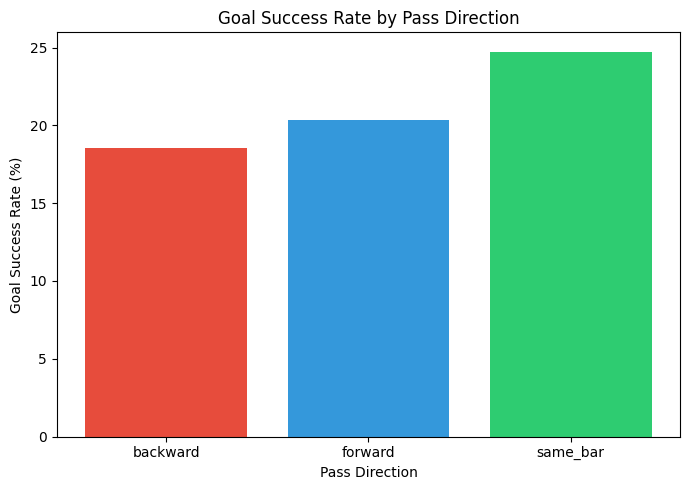

In [15]:
# Create possession ID
timestamped_data["possession_id"] = (timestamped_data["player"] != timestamped_data["player"].shift()).cumsum()
# Keep contact events
contacts_h7 = timestamped_data[timestamped_data["event_type"] == "contact"].copy()
# Clean bar names
contacts_h7["bar_clean"] = contacts_h7["bar"].str.replace(r"\d+", "", regex=True)
# Next action in same possession
contacts_h7["next_bar"] = contacts_h7.groupby("possession_id")["bar_clean"].shift(-1)
# Define field order
bar_order = {"Goal": 0, "Defense": 1, "Middle": 2, "Attack": 3}

# function for pass direction
def get_direction(row):
    if row["bar_clean"] not in bar_order or row["next_bar"] not in bar_order:
        return None  # ignore invalid rows

    if bar_order[row["next_bar"]] > bar_order[row["bar_clean"]]:
        return "forward"
    elif bar_order[row["next_bar"]] < bar_order[row["bar_clean"]]:
        return "backward"
    else:
        return "same_bar"

contacts_h7["direction"] = contacts_h7.apply(get_direction, axis=1)

# Remove invalid classifications
contacts_h7 = contacts_h7.dropna(subset=["direction"])

#Get possession goal outcome 
shot_data = (timestamped_data[timestamped_data["event_type"] == "shot"].groupby("possession_id")["is_goal"].max()
             .reset_index(name="possession_goal"))

contacts_h7 = contacts_h7.merge(shot_data, on="possession_id", how="left")
contacts_h7["possession_goal"] = contacts_h7["possession_goal"].fillna(0)

# Compute success rates
dir_stats = (contacts_h7.groupby("direction")["possession_goal"].agg(["mean", "count"]).reset_index())
dir_stats["success_rate_pct"] = dir_stats["mean"] * 100

#Plot 
plt.figure(figsize=(7, 5))

colors = {"backward": "#e74c3c","forward": "#3498db","same_bar": "#2ecc71"}

bars = plt.bar(dir_stats["direction"],dir_stats["success_rate_pct"],color=[colors[d] for d in dir_stats["direction"]])

plt.title("Goal Success Rate by Pass Direction")
plt.ylabel("Goal Success Rate (%)")
plt.xlabel("Pass Direction")
plt.tight_layout()
plt.show()

,shot_type,shots,goals,conversion_rate,conversion_rate_%
0,After pass,3906,915,0.234255,23.425499
1,Direct shot,2460,304,0.123577,12.357724


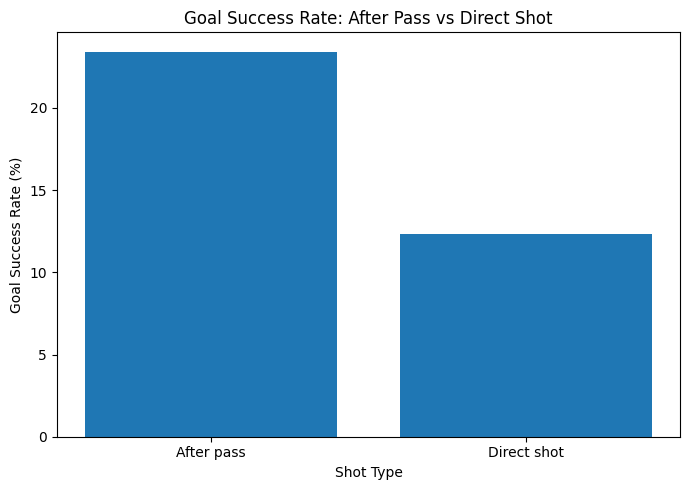

In [16]:
# Compare shots after passes with direct shots
shots_h4 = timestamped_data[timestamped_data["event_type"] == "shot"].copy()

# A possession is counted as "After pass" if it contains at least one valid pass direction
# contacts_h7 already contains valid pass movements: forward, backward, same_bar
pass_possessions = contacts_h7["possession_id"].unique()

shots_h4["shot_type"] = np.where(
    shots_h4["possession_id"].isin(pass_possessions),
    "After pass",
    "Direct shot"
)

pass_success_table = (
    shots_h4
    .groupby("shot_type")
    .agg(
        shots=("event_type", "count"),
        goals=("is_goal", "sum")
    )
    .reset_index()
)

pass_success_table["conversion_rate"] = pass_success_table["goals"] / pass_success_table["shots"]
pass_success_table["conversion_rate_%"] = pass_success_table["conversion_rate"] * 100

display(pass_success_table)

# Plot
plt.figure(figsize=(7, 5))
plt.bar(pass_success_table["shot_type"], pass_success_table["conversion_rate_%"])

plt.title("Goal Success Rate: After Pass vs Direct Shot")
plt.ylabel("Goal Success Rate (%)")
plt.xlabel("Shot Type")
plt.tight_layout()
plt.show()

### 4.2.2 Hypotheses

#### Hypothesis 4: Passes have a higher goal success rate than direct shots

H0: The goal conversion rate after passes is less than or equal to the goal conversion rate of direct shots.

H1: The goal conversion rate after passes is higher than the goal conversion rate of direct shots.

In [17]:
h4_counts = pass_success_table.set_index("shot_type")

after_pass_goals = h4_counts.loc["After pass", "goals"]
after_pass_shots = h4_counts.loc["After pass", "shots"]

direct_goals = h4_counts.loc["Direct shot", "goals"]
direct_shots = h4_counts.loc["Direct shot", "shots"]

z_stat, p_value = proportions_ztest(
    [after_pass_goals, direct_goals],
    [after_pass_shots, direct_shots],
    alternative="larger"
)

print(f"After Pass Conversion Rate: {(after_pass_goals / after_pass_shots) * 100:.2f}% ({after_pass_goals}/{after_pass_shots})")
print(f"Direct Shot Conversion Rate: {(direct_goals / direct_shots) * 100:.2f}% ({direct_goals}/{direct_shots})")
print(f"Z-Statistic: {z_stat:.4f}, p-value: {p_value:.4e}")

After Pass Conversion Rate: 23.43% (915/3906)
Direct Shot Conversion Rate: 12.36% (304/2460)
Z-Statistic: 10.9282, p-value: 4.2257e-28


The result shows that shots after passes have a higher goal conversion rate than direct shots. Shots after passes resulted in 915 goals from 3906 shots, which gives a conversion rate of 23.43%. Direct shots resulted in 304 goals from 2460 shots, with a conversion rate of 12.36%.

The p-value is below 0.05, so the null hypothesis is rejected. This means that shots after passes have a significantly higher goal conversion rate than direct shots.

Therefore, the hypothesis is supported.

#### Hypothesis 5: Olga passes the ball more than the other Players

H0: There is no statistically significant difference between the length of Olga's ball possessions and the length of the other player's ball possession.

H1: Olga has a statistically significant higher ball possession length than the other players. 

In [18]:
scaler = StandardScaler()
posession_length_values = player_posession_length["avg_posession_length"].values.reshape(-1, 1)
player_posession_length["z_score"] = scaler.fit_transform(posession_length_values)
player_posession_length.sort_values(by="z_score", ascending=True)

,player,avg_posession_length,z_score
1,Hans,2.823477,-1.257071
5,Tanja,3.105461,-0.520660
0,Diana,3.165929,-0.362747
2,Magnus,3.281563,-0.060766
4,Simon,3.384787,0.208807
3,Olga,4.067771,1.992437


Olga's average possession length is almost 2 standard deviations above the group mean. 

Statistical results:

We're using a right-tailed Welch's t-test.

We define $\mu_{\text{Olga}}$ as the mean possession length of Olga's ball possession phases and $\mu_{\text{Others}}$ as the aggregated mean possession length of the other players' phases.

$$H_0: \mu_{\text{Olga}} \le \mu_{\text{Others}}$$
$$H_1: \mu_{\text{Olga}} > \mu_{\text{Others}}$$

In [19]:
olga_possessions = timestamped_data.loc[timestamped_data["player"] == "Olga", "possession_length"]
others_possessions = timestamped_data.loc[timestamped_data["player"] != "Olga", "possession_length"]

t_stat, p_value = stats.ttest_ind(olga_possessions, others_possessions, equal_var=False, alternative="greater")
print(f"p value: {p_value:.4e}")

p value: 4.1800e-142


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 6: The goal success is higher after a pass on the same bar compared to other passes


H0: The goal success rate after a pass on the same bar is less than passing other directions.

H1: The goal's success rate after a same bar pass is significantly higher commpared to other passes.


$$H_0: p_{\text{Same-Bar}} < p_{\text{Others-Passes}}$$
$$H_1: p{\text{same-bar}} > p{\text{Others}}$$


In [20]:
# Split into groups
same_bar = contacts_h7[contacts_h7["direction"] == "same_bar"]
others = contacts_h7[contacts_h7["direction"].isin(["forward", "backward"])]

# Count goals and totals
same_bar_goals = same_bar["possession_goal"].sum()
same_bar_total = len(same_bar)

other_goals = others["possession_goal"].sum()
other_total = len(others)

# Z-test
z_stat, p_val = proportions_ztest([same_bar_goals, other_goals], [same_bar_total, other_total], alternative="larger")

print(f"Same bar: {(same_bar_goals/same_bar_total)*100:.2f}%")
print(f"Others: {(other_goals/other_total)*100:.2f}%")
print(f"p-value: {p_val:.4e}")

Same bar: 24.74%
Others: 19.42%
p-value: 1.4909e-04


The p-value is below 0.05. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 7: The goal success is higher after back passes (e.g. Attack -> Middle) than after forward passes or direct shots

H0: Success rate of Back Passes is less or equal to the success rate of others.

H1: Success rate of Back Passes is strictly greater than the success rate of others.

In [21]:
# Split into groups 
back = contacts_h7[contacts_h7["direction"] == "backward"]
others = contacts_h7[contacts_h7["direction"].isin(["forward", "same_bar"])]

# Count goals and totals
back_goals = back["possession_goal"].sum()
back_total = len(back)

other_goals = others["possession_goal"].sum()
other_total = len(others)

# Z-test
z_stat, p_val = proportions_ztest([back_goals, other_goals], [back_total, other_total], alternative="larger")

print(f"Back: {(back_goals/back_total)*100:.2f}%") 
print(f"Others: {(other_goals/other_total)*100:.2f}%")
print(f"Z-stat: {z_stat:.4f}, p-value: {p_val:.4f}")

Back: 18.56%
Others: 20.88%
Z-stat: -3.2712, p-value: 0.9995


Statistical Results: With a p-value of 0.9995, the results are not statistically significant (p > 0.05).

Therefore, we fail to reject the null hypothesis. There is not enough evidence to support the claim that back passes lead to a higher goal success rate than forward or same-bar passes.

Although back passes show a slightly lower success rate (18.56%) compared to other passes (20.88%), this difference is not statistically meaningful.

#### Hypothesis 8: Diana has a higher goal success after a Middle -> Middle pass compared to other passes or direct shots

H0: Diana's goal conversion rate after same-bar passes is less than or equal to her goal conversion rate after other pass directions.

H1: Diana's goal conversion rate after same-bar passes is higher than her goal conversion rate after other pass directions.


In [22]:
diana_same_bar_possessions = contacts_h7[
    (contacts_h7["player"] == "Diana") &
    (contacts_h7["direction"] == "same_bar")
]["possession_id"].unique()

diana_shots_h8 = timestamped_data[
    (timestamped_data["event_type"] == "shot") &
    (timestamped_data["player"] == "Diana")
].copy()

diana_shots_h8["pass_type"] = np.where(
    diana_shots_h8["possession_id"].isin(diana_same_bar_possessions),
    "After same-bar pass",
    "After other/no pass"
)

same_bar = diana_shots_h8[diana_shots_h8["pass_type"] == "After same-bar pass"]
other_passes = diana_shots_h8[diana_shots_h8["pass_type"] == "After other/no pass"]

same_bar_goals = same_bar["is_goal"].sum()
same_bar_shots = same_bar["is_shot"].sum()

other_goals = other_passes["is_goal"].sum()
other_shots = other_passes["is_shot"].sum()

z_stat, p_value = proportions_ztest(
    [same_bar_goals, other_goals],
    [same_bar_shots, other_shots],
    alternative="larger"
)

print(f"Diana Same-Bar Pass Conversion Rate: {(same_bar_goals / same_bar_shots) * 100:.2f}% ({same_bar_goals}/{same_bar_shots})")
print(f"Diana Other/No Pass Conversion Rate: {(other_goals / other_shots) * 100:.2f}% ({other_goals}/{other_shots})")
print(f"Z-Statistic: {z_stat:.4f}, p-value: {p_value:.6f}")

Diana Same-Bar Pass Conversion Rate: 43.70% (52/119)
Diana Other/No Pass Conversion Rate: 22.79% (188/825)
Z-Statistic: 4.8971, p-value: 0.000000


he result shows that Diana has a higher goal conversion rate after same-bar passes. Diana scored 52 goals from 119 shots after same-bar passes, which gives a conversion rate of 43.70%. After other or no passes, she scored 188 goals from 825 shots, with a conversion rate of 22.79%.

The p-value is below 0.05, so the null hypothesis is rejected. This means that Diana's goal conversion rate after same-bar passes is significantly higher than after other or no passes.

Therefore, the hypothesis is supported.

## 4.3 Shot Execution and Offensive Efficiency

### 4.3.1 Plots and Results

#### Shot Conversion Rate

In [23]:
player_conversion_rate = timestamped_data.groupby('player').agg(shots=('is_shot','sum'), goals=('is_goal', 'sum')).reset_index()
player_conversion_rate['conversion_rate'] = (player_conversion_rate['goals'] / player_conversion_rate['shots'])
player_conversion_rate.sort_values(by='conversion_rate', ascending=False)

,player,shots,goals,conversion_rate
3,Olga,664,223,0.335843
0,Diana,944,240,0.254237
2,Magnus,1002,186,0.185629
5,Tanja,1141,189,0.165644
4,Simon,1368,219,0.160088
1,Hans,1247,162,0.129912


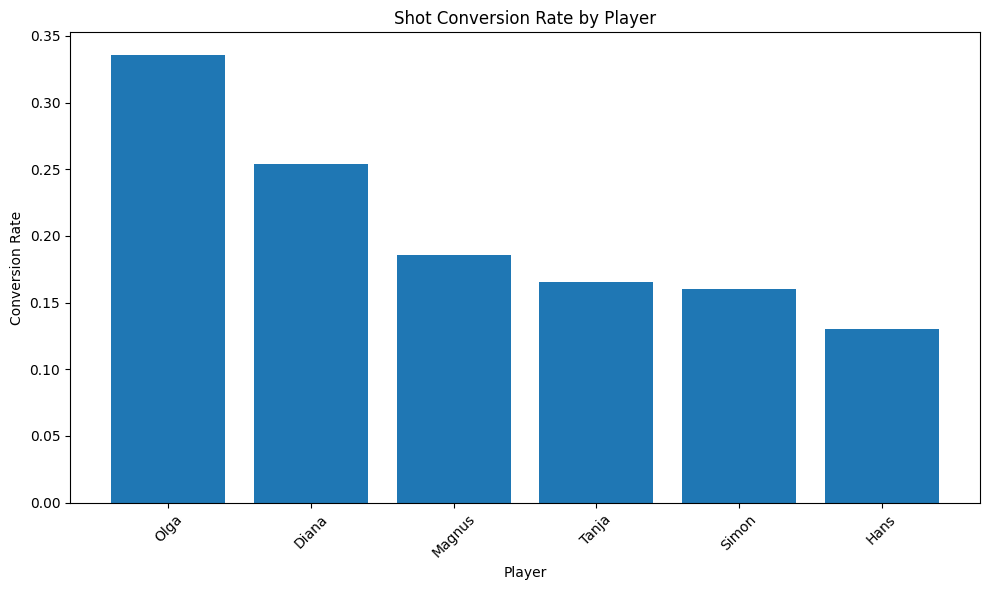

In [24]:
player_conversion_rate = player_conversion_rate.sort_values(
    by='conversion_rate',
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.bar(
    player_conversion_rate['player'],
    player_conversion_rate['conversion_rate'])

plt.title('Shot Conversion Rate by Player')
plt.xlabel('Player')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### Simon Long Shots

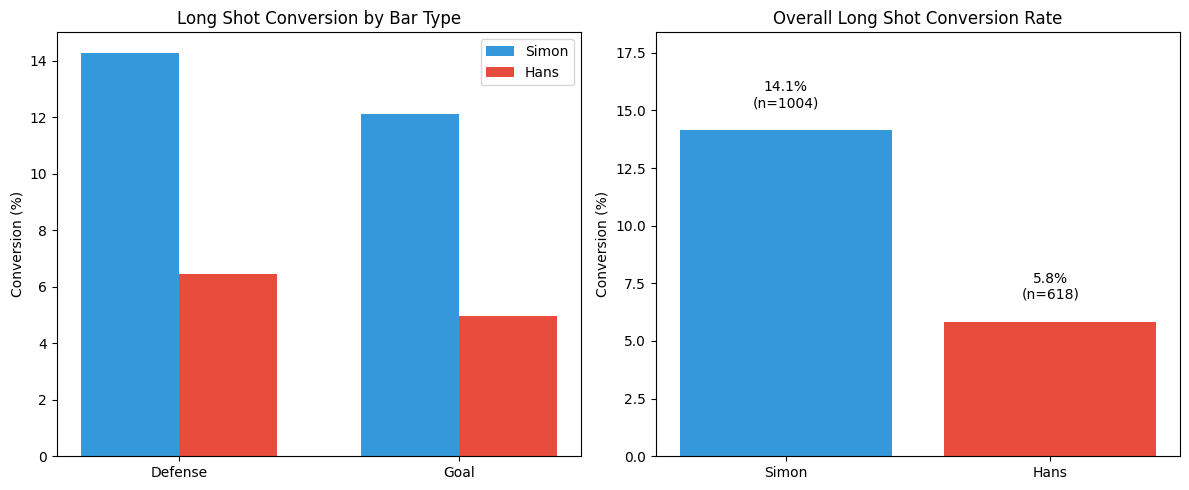

In [25]:
# Get shot events
shots_h14 = timestamped_data[timestamped_data["event_type"] == "shot"].copy()
# Clean bar names
shots_h14["bar_clean"] = shots_h14["prev_bar"].str.replace(r"\d+", "", regex=True)

# Filter for long shots
long_shots_h14 = shots_h14[shots_h14["bar_clean"].isin(["Goal", "Defense"]) & shots_h14["player"].isin(["Simon", "Hans"])].copy()

long_shots_h14["is_goal_int"] = long_shots_h14["is_goal"].astype(int)

# Conversion per bar
bar_conv_h14 = (long_shots_h14.groupby(["player", "bar_clean"])["is_goal_int"].agg(["sum", "count"]).reset_index())
bar_conv_h14["conv_pct"] = bar_conv_h14["sum"] / bar_conv_h14["count"] * 100

# Overall conversion per player
total_conv_h14 = (long_shots_h14.groupby("player")["is_goal_int"].agg(["sum", "count"]).reset_index())
total_conv_h14["conv_pct"] = total_conv_h14["sum"] / total_conv_h14["count"] * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars = sorted(bar_conv_h14["bar_clean"].unique())
x = np.arange(len(bars))
width = 0.35

# Left plot (by bar type)
def get_val(df, player, bar):
    match = df[(df["player"] == player) & (df["bar_clean"] == bar)]
    return match["conv_pct"].values[0] if len(match) else 0

axes[0].bar(x - width/2, [get_val(bar_conv_h14, "Simon", b) for b in bars], width, label="Simon", color="#3498db")
axes[0].bar(x + width/2, [get_val(bar_conv_h14, "Hans", b) for b in bars], width, label="Hans", color="#e74c3c")

axes[0].set_xticks(x)
axes[0].set_xticklabels(bars)
axes[0].set_title("Long Shot Conversion by Bar Type")
axes[0].set_ylabel("Conversion (%)")
axes[0].legend()

# Right plot (Overall long shots)
players = ["Simon", "Hans"]
colors = ["#3498db", "#e74c3c"]

axes[1].set_ylim(0, total_conv_h14["conv_pct"].max() * 1.3)
for i, (p, c) in enumerate(zip(players, colors)):
    row = total_conv_h14[total_conv_h14["player"] == p].iloc[0]

    axes[1].bar(p, row["conv_pct"], color=c)

    axes[1].text(i, row["conv_pct"] + 1, f"{row['conv_pct']:.1f}%\n(n={int(row['count'])})", ha="center")

axes[1].set_title("Overall Long Shot Conversion Rate")
axes[1].set_ylabel("Conversion (%)")
plt.tight_layout()
plt.show()

#### Shot Conversion Rate by Bar

In [26]:
bar_stats = shots.groupby("prev_bar_clean")["is_goal"].agg(total_shots="count",goals="sum",conversion_rate="mean").reset_index()
bar_stats.sort_values(by='conversion_rate', ascending=False)

,prev_bar_clean,total_shots,goals,conversion_rate
0,Attack,1798,650,0.361513
3,Middle,1504,223,0.148271
1,Defense,1980,244,0.123232
2,Goal,803,65,0.080946


### 4.3.2 Hypotheses

#### Hypothesis 9: Olga demonstrates the highest shot conversion rate.

H0: There is no statistically significant difference between Olga's shot conversion rate and the conversion rate of the other players.

H1: Olga has a statistically significant higher shot conversion rate compared to the other players.

In [27]:
scaler = StandardScaler()
scaler.fit(player_conversion_rate["conversion_rate"].values.reshape(-1, 1))
z_scores = scaler.transform(player_conversion_rate["conversion_rate"].values.reshape(-1, 1))
player_conversion_rate["z_score"] = z_scores
player_conversion_rate.sort_values(by="z_score", ascending=False)

,player,shots,goals,conversion_rate,z_score
3,Olga,664,223,0.335843,1.874807
0,Diana,944,240,0.254237,0.703484
2,Magnus,1002,186,0.185629,-0.281280
5,Tanja,1141,189,0.165644,-0.568126
4,Simon,1368,219,0.160088,-0.647880
1,Hans,1247,162,0.129912,-1.081006


Olga's conversion rate is almost 1.9 standard deviations above the group mean.

Statistical results:

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Olga}}$ as the shot conversion rate (proportion of goals to total shots) of Olga and $p_{\text{Others}}$ as the aggregated shot conversion rate of the other players.

$$H_0: p_{\text{Olga}} \le p_{\text{Others}}$$
$$H_1: p_{\text{Olga}} > p_{\text{Others}}$$

In [28]:
olga_goals = timestamped_data.loc[timestamped_data['player'] == 'Olga', 'is_goal'].sum()
olga_shots = timestamped_data.loc[timestamped_data['player'] == 'Olga', 'is_shot'].sum()

others_goals = timestamped_data.loc[timestamped_data['player'] != 'Olga', 'is_goal'].sum()
others_shots = timestamped_data.loc[timestamped_data['player'] != 'Olga', 'is_shot'].sum()

goals = [olga_goals, others_goals]
observations = [olga_shots, others_shots]

z_stat, p_value = proportions_ztest(goals, observations, alternative='larger')

print(f"p value: {p_value:.4e}")

p value: 8.4981e-24


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 10: Players who have a attack bias scores a higher number of goals compared to the other players.

**H0**: There is no statistically significant correlation between attack bias and goals scored by players.

**H1**: Players have a statistically significant positive correlation between attack bias and goal scored.

In [29]:
# Extracting attack specific data 
group_cols = ["player", "game"] 
contacts = timestamped_data[timestamped_data["event_type"] == "contact"]
total_contacts = contacts.groupby(group_cols).size()
attack_contact = contacts[contacts["bar"].str.contains("Attack", na=False)].groupby(group_cols).size()  # strips Attack1 to Attack
# We need 2 main  features 'Attack Bias' & 'Total Goals'
attack_bias = (attack_contact / total_contacts).rename("attack_bias").fillna(0)
goals = timestamped_data[(timestamped_data["event_type"] == "shot") & (timestamped_data["is_goal"] == True)]
total_goals = goals.groupby(group_cols).size().rename("total_goals")
player_h2 = pd.concat([attack_bias,total_goals], axis=1).fillna(0)
# Testing the co-relation using stats.pearson

correlation, p_value = stats.pearsonr(player_h2['attack_bias'], player_h2['total_goals'])

print(f"p_value = {p_value:.4f}")
print(correlation)


p_value = 0.5357
0.11768859471281078


In [30]:
player_h2

attack_bias  total_goals
player game                                  
Diana  Diana-Hans       0.225806           50
       Diana-Magnus     0.233937           45
       Diana-Olga       0.257658           50
       Diana-Simon      0.257603           45
       Diana-Tanja      0.227941           50
Hans   Diana-Hans       0.154008           24
       Hans-Magnus      0.221311           35
       Hans-Olga        0.219959           30
       Hans-Simon       0.231237           27
       Hans-Tanja       0.220109           46
Magnus Diana-Magnus     0.172596           33
       Hans-Magnus      0.197115           50
       Magnus-Olga      0.227053           33
       Magnus-Simon     0.207273           35
       Magnus-Tanja     0.204268           35
Olga   Diana-Olga       0.188488           35
       Hans-Olga        0.186457           49
       Magnus-Olga      0.203640           44
       Olga-Simon       0.217687           45
       Olga-Tanja       0.182416           50
Simon  Diana-Simon      0.139183           36
       Hans-Simon       0.153153           50
       Magnus-Simon     0.184874           47
       Olga-Simon       0.171390           42
       Simon-Tanja      0.155828           44
Tanja  Diana-Tanja      0.187402           30
       Hans-Tanja       0.173505           47
       Magnus-Tanja     0.185065           38
       Olga-Tanja       0.215262           35
       Simon-Tanja      0.209268           39

Statistical Results:
With a p-value of $0.54$, the results are not statistically significant ($p > 0.05$). 

Therefore, we cannot reject the null hypothesis. There is no evidence in this data to support the claim that a higher attack bias leads to a greater number of goals.

#### Hypothesis 11: Diana shoots more shots from the left side than the other players

H0: There is no significant difference in the amount of shots taken from the left side for Olga compared to the other players

H1: Olga takes significantly more shots from the left side than the other players.

In [31]:
player_side_percentages = timestamped_data[timestamped_data['is_shot']].groupby('player')['prev_side_normalized'].value_counts(normalize=True).reset_index(name='percentage')
player_side_percentages['percentage'] = player_side_percentages['percentage'] * 100

left_side_shots = player_side_percentages[player_side_percentages['prev_side_normalized'] == 'Left']
left_side_shots.sort_values(by='percentage', ascending=False)

,player,prev_side_normalized,percentage
0,Diana,Left,66.313559
5,Hans,Left,27.826784
8,Magnus,Left,26.746507
14,Simon,Left,26.096491
11,Olga,Left,23.945783
17,Tanja,Left,21.472393


In [32]:
scaler = StandardScaler()
scaler.fit(left_side_shots["percentage"].values.reshape(-1, 1))
z_scores = scaler.transform(left_side_shots["percentage"].values.reshape(-1, 1))
left_side_shots["z_score"] = z_scores
left_side_shots.sort_values(by="z_score", ascending=False)

,player,prev_side_normalized,percentage,z_score
0,Diana,Left,66.313559,2.216034
5,Hans,Left,27.826784,-0.274371
8,Magnus,Left,26.746507,-0.344274
14,Simon,Left,26.096491,-0.386335
11,Olga,Left,23.945783,-0.525503
17,Tanja,Left,21.472393,-0.685551


Diana takes two thirds of shots from the left side.

Olga's amount of shots taken from the left side are more than two standard deviations above the group mean.

### Statistical Results


We're using a right-tailed Z-test for proportions.

We define $p_{\text{Diana}}$ as the proportion of shots taken from the left side by Diana and $p_{\text{Others}}$ as the aggregated proportion of shots taken from the left side by the other players.

$$H_0: p_{\text{Diana}} \le p_{\text{Others}}$$
$$H_1: p_{\text{Diana}} > p_{\text{Others}}$$

In [33]:
diana_left = timestamped_data[(timestamped_data['player'] == 'Diana') & (timestamped_data['is_shot'] == True) & (timestamped_data['prev_side_normalized'] == 'Left')].shape[0]
diana_total_shots = timestamped_data[(timestamped_data['player'] == 'Diana') & (timestamped_data['is_shot'] == True)].shape[0]

others_left = timestamped_data[(timestamped_data['player'] != 'Diana') & (timestamped_data['is_shot'] == True) & (timestamped_data['prev_side_normalized'] == 'Left')].shape[0]
others_total_shots = timestamped_data[(timestamped_data['player'] != 'Diana') & (timestamped_data['is_shot'] == True)].shape[0]

successes = [diana_left, others_left]
observations = [diana_total_shots, others_total_shots]

z_stat, p_value = proportions_ztest(successes, observations, alternative='larger')

print(f"p value: {p_value:.4e}")

p value: 3.1260e-138


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 12: Shots taken from the Defense bar or Goal bar have a lower goal conversion rate compared to shots from Middle/Attack bar

H0: There is no significant difference in the success of shots taken from the Defense or Goal bar compared to the success of shots taken from the Middle or Attack bar.

H1: Shots taken from the Defense or Goal bar are significantly less successful than shots taken from the Middle or Attack bar. 

In [34]:
scaler = StandardScaler()
rates_reshaped = bar_stats["conversion_rate"].values.reshape(-1, 1)
bar_stats["z_score"] = scaler.fit_transform(rates_reshaped)
bar_stats.sort_values(by="conversion_rate", ascending=True)

,prev_bar_clean,total_shots,goals,conversion_rate,z_score
2,Goal,803,65,0.080946,-0.900081
1,Defense,1980,244,0.123232,-0.509892
3,Middle,1504,223,0.148271,-0.278847
0,Attack,1798,650,0.361513,1.688819


The average conversion rate of shots taken from the Goal bar is 0.9 standard deviation below the group mean. The conversion rate of shots taken from the Attack bar is almost 1.7 standard deviations above the group mean. The Defense and Middle bar have average conversion rates below the group mean with the middle bar having a higher conversion rate than the Defense bar.

Statistical results:

We're using a left-tailed Z-test for proportions.

We define $p_{\text{Def/Goal}}$ as the goal conversion rate of shots taken from the defense or goal bars, and $p_{\text{Mid/Att}}$ as the conversion rate of shots taken from the middle or attack bars.

$$H_0: p_{\text{Def/Goal}} \ge p_{\text{Mid/Att}}$$
$$H_1: p_{\text{Def/Goal}} < p_{\text{Mid/Att}}$$

In [36]:
def_goal_shots = shots[shots["prev_bar_clean"].isin(["Defense", "Goal"])]
mid_att_shots = shots[shots["prev_bar_clean"].isin(["Middle", "Attack"])]

success_def_goal = def_goal_shots["is_goal"].sum()
obs_def_goal = def_goal_shots.shape[0]

success_mid_att = mid_att_shots["is_goal"].sum()
obs_mid_att = mid_att_shots.shape[0]

successes = [success_def_goal, success_mid_att]
observations = [obs_def_goal, obs_mid_att]

z_stat, p_value = proportions_ztest(successes, observations, alternative='smaller')
print(f"p value: {p_value:.4e}")

p value: 1.4038e-51


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 13: Simon and Hans take more shots from the Goal and Defense bar than the other players.

H0: There is no significant difference in the success of shots taken from the Defense or Goal bar for Simon and Hans compared to the success of shots for other playrs.

H1: Shots taken by Simon and Hans from the Defense or Goal bar are significantly high than shots taken by other players from these bars. 

In [38]:
# Filter long shots for all players
all_long_shots = shots[shots["prev_bar_clean"].isin(["Goal", "Defense"])]

# Split by group
simon_hans_long = all_long_shots[all_long_shots["player"].isin(["Simon", "Hans"])]
others_long = all_long_shots[all_long_shots["player"].isin(["Diana", "Olga", "Tanja", "Magnus"])]

# Count long shots per group
shot_long = simon_hans_long.shape[0]
others_long = others_long.shape[0]

# Total shots per group (denominator)
shot_total = shots[shots["player"].isin(["Simon", "Hans"])].shape[0]
others_total = shots[shots["player"].isin(["Diana", "Olga", "Tanja", "Magnus"])].shape[0]

successes = [shot_long, others_long]
observations = [shot_total, others_total]

z_stat, p_value = proportions_ztest(successes, observations, alternative="larger")

print(f"p value: {p_value:.4e}")

p value: 1.7465e-109


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 14: Simon is more successful for his long shots than Hans. 

H0: Simon's long shot conversion rate is less or equal to Hans's conversion rate.

H1: Simon's long shot conversion rate is greater than Hans's conversion rate.

In [39]:
# Split by players
simon_h14 = long_shots_h14[long_shots_h14["player"] == "Simon"]
hans_h14 = long_shots_h14[long_shots_h14["player"] == "Hans"]

# Count goal and shots for each
simon_goals = simon_h14["is_goal_int"].sum()
simon_shots = len(simon_h14)

hans_goals = hans_h14["is_goal_int"].sum()
hans_shots = len(hans_h14)

# Z-test
z_stat, p_val = proportions_ztest([simon_goals, hans_goals],[simon_shots, hans_shots],alternative="larger")

# Array to compare
rates = np.array([simon_goals / simon_shots,hans_goals / hans_shots])
z_scores = (rates - rates.mean()) / (rates.std() + 1e-9)

print(f"Simon: {simon_goals}/{simon_shots} = {rates[0]*100:.2f}%")
print(f"Hans : {hans_goals}/{hans_shots} = {rates[1]*100:.2f}%")
print(f"p-value: {p_val}")

Simon: 142/1004 = 14.14%
Hans : 36/618 = 5.83%
p-value: 9.699399637298483e-08


Statistical Results: With a p-value of 9.70e-08, the results are highly statistically significant (p < 0.05).

Therefore, we reject the null hypothesis. There is strong evidence to support the claim that Simon has a higher long-shot goal conversion rate than Hans.

There is a clear difference in long-shot performance, with Simon converting 14.14% of long shots compared to 5.83% for Hans.

#### Hypothesis 15: Hans has a lower conversion rate ? 

H0: Hans's shot conversion rate is greater than or equal to the shot conversion rate of the other players.

H1: Hans's shot conversion rate is lower than the shot conversion rate of the other players.

We use a left-tailed two-proportion z-test.

In [40]:
hans_goals = timestamped_data.loc[
    timestamped_data["player"] == "Hans", "is_goal"
].sum()

hans_shots = timestamped_data.loc[
    timestamped_data["player"] == "Hans", "is_shot"
].sum()

others_goals = timestamped_data.loc[
    timestamped_data["player"] != "Hans", "is_goal"
].sum()

others_shots = timestamped_data.loc[
    timestamped_data["player"] != "Hans", "is_shot"
].sum()

hans_rate = hans_goals / hans_shots * 100 if hans_shots > 0 else 0
others_rate = others_goals / others_shots * 100 if others_shots > 0 else 0

z_statistic, p_value = proportions_ztest(
    count=[hans_goals, others_goals],
    nobs=[hans_shots, others_shots],
    alternative="smaller"
)

print(f"Hans Conversion Rate: {hans_rate:.2f}% ({hans_goals}/{hans_shots})")
print(f"Other Players Conversion Rate: {others_rate:.2f}% ({others_goals}/{others_shots})")
print(f"Z-Statistic: {z_statistic:.4f}, p-value: {p_value:.6f}")

Hans Conversion Rate: 12.99% (162/1247)
Other Players Conversion Rate: 20.65% (1057/5119)
Z-Statistic: -6.1626, p-value: 0.000000


The result shows that Hans has a lower goal conversion rate than the other players. Hans scored 162 goals from 1247 shots, which gives a conversion rate of 12.99%. The other players scored 1057 goals from 5119 shots, with a conversion rate of 20.65%.

The p-value is below 0.05, so the null hypothesis is rejected. This means that Hans' goal conversion rate is significantly lower than the goal conversion rate of the other players.

Therefore, the hypothesis is supported.

## 4.4 Defensive Behaviour

### 4.4.1 Plots and Results

#### Player Defensive Recovery Rate

In [41]:
players = timestamped_data["player"].dropna().unique()
stats_list = []

# Track what happens immediately after each event with shifted columns
df_h17 = timestamped_data.copy()
df_h17["next_player"] = df_h17.groupby(["game", "run_id"])["player"].shift(-1)
df_h17["next_bar"] = df_h17.groupby(["game", "run_id"])["bar"].shift(-1)

#Loop through each player
for p in players:

    games = round_data[(round_data["player_1"] == p) | (round_data["player_2"] == p)]
    # Calculate win_rate
    win_rate = (games["round_winner"] == p).mean() if len(games) > 0 else 0
    # Find shots by the opponent while this player is involved in the round 
    opp_shots = df_h17[(df_h17["event_type"] == "shot") & (df_h17["player"] != p) & ((df_h17["player_1"] == p) | (df_h17["player_2"] == p))]
    # Check if the player regains possession immediately after the shot and the next action happens in a defensive area
    recoveries = opp_shots[(opp_shots["next_player"] == p) & (opp_shots["next_bar"].str.contains("Defense|Goal", na=False))]

    # Recovery rate = successful recoveries / total opponent shots
    recov_rate = len(recoveries) / len(opp_shots) if len(opp_shots) > 0 else 0

    #Store results for each player
    stats_list.append({"Player": p, "Win Rate": win_rate, "Recovery Rate": recov_rate})

recov_df = pd.DataFrame(stats_list)

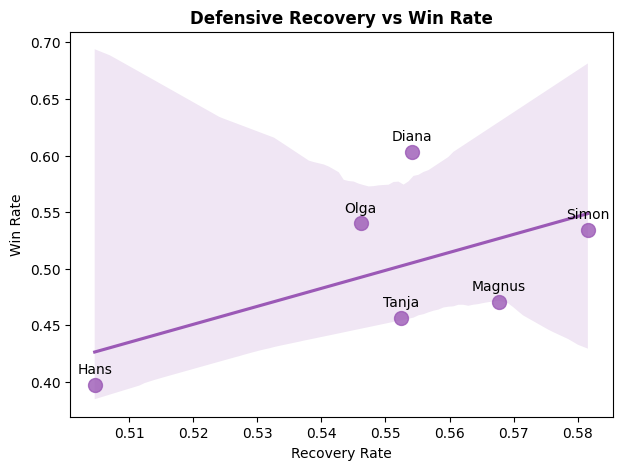

In [42]:
plt.figure(figsize=(7, 5))
sns.regplot(data=recov_df, x="Recovery Rate", y="Win Rate", color="#9b59b6", scatter_kws={'s':100})
for i, row in recov_df.iterrows():
    plt.text(row["Recovery Rate"], row["Win Rate"]+0.01, row["Player"], horizontalalignment='center')
plt.title("Defensive Recovery vs Win Rate", fontweight="bold")
plt.show()

### 4.4.2 Hypotheses

#### Hypothesis 16: Simon and Magnus have stronger defensive recovery behavior than the other Players

H0: Simon and Magnus do not have a higher defensive recovery rate than the other players.

H1: Simon and Magnus have a higher defensive recovery rate than the other players.


In [43]:
df_h16 = timestamped_data.copy()

df_h16["next_player"] = df_h16.groupby(["game", "run_id"])["player"].shift(-1)
df_h16["next_bar"] = df_h16.groupby(["game", "run_id"])["bar"].shift(-1)

target_players = ["Simon", "Magnus"]

for target_player in target_players:
    
    target_opp_shots = df_h16[
        (df_h16["event_type"] == "shot") &
        (df_h16["player"] != target_player) &
        (
            (df_h16["player_1"] == target_player) |
            (df_h16["player_2"] == target_player)
        )
    ]
    
    target_recoveries = target_opp_shots[
        (target_opp_shots["next_player"] == target_player) &
        (target_opp_shots["next_bar"].str.contains("Defense|Goal", na=False))
    ]
    
    target_recovery_count = len(target_recoveries)
    target_shots_faced = len(target_opp_shots)
    
    other_recovery_count = 0
    other_shots_faced = 0
    
    for other_player in players:
        if other_player != target_player:
            
            other_opp_shots = df_h16[
                (df_h16["event_type"] == "shot") &
                (df_h16["player"] != other_player) &
                (
                    (df_h16["player_1"] == other_player) |
                    (df_h16["player_2"] == other_player)
                )
            ]
            
            other_recoveries = other_opp_shots[
                (other_opp_shots["next_player"] == other_player) &
                (other_opp_shots["next_bar"].str.contains("Defense|Goal", na=False))
            ]
            
            other_recovery_count += len(other_recoveries)
            other_shots_faced += len(other_opp_shots)
    
    z_stat, p_value = proportions_ztest(
        [target_recovery_count, other_recovery_count],
        [target_shots_faced, other_shots_faced],
        alternative="larger"
    )
    
    print(f"{target_player} Recovery Rate: {(target_recovery_count / target_shots_faced) * 100:.2f}% ({target_recovery_count}/{target_shots_faced})")
    print(f"Other Players Recovery Rate: {(other_recovery_count / other_shots_faced) * 100:.2f}% ({other_recovery_count}/{other_shots_faced})")
    print(f"Z-Statistic: {z_stat:.4f}, p-value: {p_value:.6f}")
    print()

Simon Recovery Rate: 58.16% (563/968)
Other Players Recovery Rate: 54.61% (2948/5398)
Z-Statistic: 2.0441, p-value: 0.020474

Magnus Recovery Rate: 56.77% (675/1189)
Other Players Recovery Rate: 54.78% (2836/5177)
Z-Statistic: 1.2440, p-value: 0.106751



Statistical Results: For Simon, the p-value is 0.0205, which is below 0.05. Therefore, we reject the null hypothesis for Simon. There is enough evidence to support that Simon has a higher defensive recovery rate than the other players.

For Magnus, the p-value is 0.1068, which is above 0.05. Therefore, we fail to reject the null hypothesis for Magnus. There is not enough statistical evidence to support that Magnus has a higher defensive recovery rate than the other players.

Overall, Hypothesis 16 is partially supported. It is statistically supported for Simon, but not for Magnus.

#### Hypothesis 17: Players with higher defensive recovery rates win more games

H0: There is no correlation between recovery rate and win rate.

H1: There is a positive correlation.

In [44]:
# Pearson Correlation Test
r_stat, p_val = stats.pearsonr(recov_df["Recovery Rate"], recov_df["Win Rate"])

print(f"Pearson Correlation (r): {r_stat}")
print(f"P-Value: {p_val}")

Pearson Correlation (r): 0.5672917332682761
P-Value: 0.24034528754963652


Statistical Results: With a p-value of 0.240, the results are not statistically significant (p > 0.05).

Therefore, we fail to reject the null hypothesis. There is not enough evidence to support a meaningful relationship between recovery rate and win rate.

Although the Pearson correlation coefficient (r = 0.567) suggests a moderate positive relationship, this pattern is not statistically reliable and could be due to random variations.

#### Hypothesis 18: The other players have a higher shot-conversion rate when playing against Hans.

H0: Other players do not have a higher shot-conversion rate when playing against Hans compared to when they play against other players.

H1: Other players have a higher shot-conversion rate when playing against Hans compared to when they play against other players.

In [45]:
other_players_shots = timestamped_data[
    (timestamped_data["event_type"] == "shot") &
    (timestamped_data["player"] != "Hans")
].copy()

against_hans_goals = other_players_shots.loc[
    (other_players_shots["player_1"] == "Hans") |
    (other_players_shots["player_2"] == "Hans"),
    "is_goal"
].sum()

against_hans_shots = other_players_shots.loc[
    (other_players_shots["player_1"] == "Hans") |
    (other_players_shots["player_2"] == "Hans"),
    "is_shot"
].sum()

against_others_goals = other_players_shots.loc[
    (other_players_shots["player_1"] != "Hans") &
    (other_players_shots["player_2"] != "Hans"),
    "is_goal"
].sum()

against_others_shots = other_players_shots.loc[
    (other_players_shots["player_1"] != "Hans") &
    (other_players_shots["player_2"] != "Hans"),
    "is_shot"
].sum()

goals = [against_hans_goals, against_others_goals]
observations = [against_hans_shots, against_others_shots]

z_stat, p_value = proportions_ztest(goals, observations, alternative="larger")

print(f"Against Hans Conversion Rate: {(against_hans_goals / against_hans_shots) * 100:.2f}% ({against_hans_goals}/{against_hans_shots})")
print(f"Against Other Players Conversion Rate: {(against_others_goals / against_others_shots) * 100:.2f}% ({against_others_goals}/{against_others_shots})")
print(f"Z-Statistic: {z_stat:.4f}, p-value: {p_value:.6f}")

Against Hans Conversion Rate: 25.03% (246/983)
Against Other Players Conversion Rate: 19.61% (811/4136)
Z-Statistic: 3.7716, p-value: 0.000081


The p-value is 0.000081, which is below 0.05. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

This means that other players have a significantly higher shot conversion rate when playing against Hans compared to when playing against other players.

## 4.5 Matchup-Specific Patterns

### 4.5.1 Plots and Results

#### Games for Diana and Hans have less events

In [46]:
# Count events per game
event_counts = timestamped_data.groupby(["game", "run_id"]).size().reset_index(name="event_count")

# Filter for Diana-Hans vs Others
diana_hans_games = event_counts[event_counts["game"].str.contains("Diana-Hans|Hans-Diana", case=False)]
other_games = event_counts[~event_counts["game"].str.contains("Diana-Hans|Hans-Diana", case=False)]
# Extract event counts per game for Diana–Hans matchups and all other matchups
dh_counts = diana_hans_games["event_count"].values
other_counts = other_games["event_count"].values


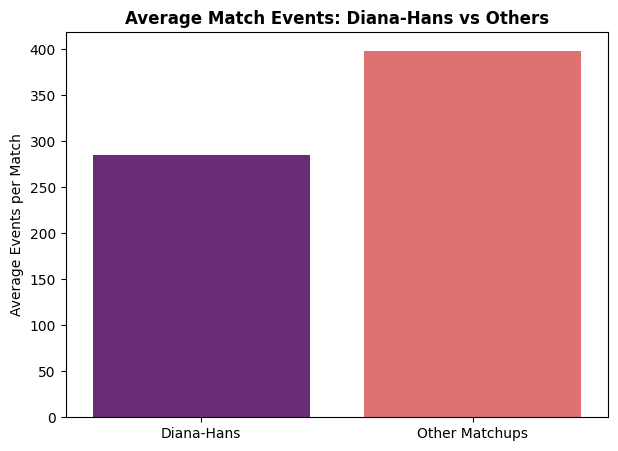

In [47]:
plt.figure(figsize=(7, 5))
sns.barplot(x=["Diana-Hans", "Other Matchups"], y=[dh_counts.mean(), other_counts.mean()], hue=["Diana-Hans", "Other Matchups"], palette="magma")
plt.title("Average Match Events: Diana-Hans vs Others", fontweight="bold")
plt.ylabel("Average Events per Match")
plt.show()

### 4.5.2 Hypotheses

#### Hypothesis 19: Magnus wins less against Hans than against anyone else

**H0:** Magnus's win rate against Hans ≥ his win rate against other players  
**H1:** Magnus's win rate against Hans < his win rate against other players  

In [48]:
magnus_rounds = round_data[(round_data["player_1"] == "Magnus") | (round_data["player_2"] == "Magnus")].copy()
magnus_rounds["magnus_won"] = magnus_rounds["round_winner"] == "Magnus"
magnus_rounds["opponent"] = np.where(
    magnus_rounds["player_1"] == "Magnus",
    magnus_rounds["player_2"],
    magnus_rounds["player_1"]
)
# Split into groups
magnus_hans = magnus_rounds[magnus_rounds["opponent"] == "Hans"]
magnus_others = magnus_rounds[magnus_rounds["opponent"] != "Hans"]

# Count wins and total rounds
hans_wins = magnus_hans["magnus_won"].sum()
hans_total = len(magnus_hans)

others_wins = magnus_others["magnus_won"].sum()
others_total = len(magnus_others)

# Z-test (left-tailed: Magnus wins less against Hans)
z_stat, p_value = proportions_ztest([hans_wins, others_wins], [hans_total, others_total], alternative="smaller")

print(f"Magnus vs Hans  : {hans_wins}/{hans_total} = {hans_wins/hans_total*100:.2f}%")
print(f"Magnus vs Others: {others_wins}/{others_total} = {others_wins/others_total*100:.2f}%")
print(f"p value: {p_value:.4f}")

Magnus vs Hans  : 50/85 = 58.82%
Magnus vs Others: 136/310 = 43.87%
p value: 0.9928


p-value is more than 0.05, so we failed to reject the null hypothesis. 

#### Hypothesis 20: Games for Diana and Hans have less events than the games for the other matchups.

H0: Average events in Diana-Hans games is greater or equal to other games.

H1: Average events in Diana-Hans games less other games.

In [49]:
# Welch's T-Test
t_stat, p_val = stats.ttest_ind(dh_counts, other_counts, equal_var=False, alternative='less')

print(f"Diana-Hans Avg Events/Game: {dh_counts.mean():.1f} (n={len(dh_counts)})")
print(f"Other Matchups Avg Events/Game: {other_counts.mean():.1f} (n={len(other_counts)})")
print(f"Welch's T-Statistic: {t_stat:.4f}, p-value: {p_val:.4f}")


Diana-Hans Avg Events/Game: 285.6 (n=5)
Other Matchups Avg Events/Game: 398.7 (n=70)
Welch's T-Statistic: -2.6557, p-value: 0.0224


Statistical Results: With a p-value of 0.0224, the results are statistically significant (p < 0.05).

Therefore, we reject the null hypothesis. There is sufficient evidence to support the claim that Diana–Hans matchups have less events per game (285.6) compared to other matchups (398.7). Therefore, these matches tend to be less event-heavy.

----------------------------